# Etapa 2 — Modelagem e Avaliação

**Disciplina:** Fundamentos de Modelos de ML
**Foco:** Treinamento, comparação e avaliação de modelos de classificação de churn

Este notebook dá continuidade ao `eda_churn_prediction.ipynb` (Etapa 1), reaproveitando os dados
já pré-processados (imputação, feature engineering, one-hot encoding e seleção de features) e o
baseline de Regressão Logística já treinado e tunado.

**Tarefas desta etapa:**
1. Treinar um modelo baseado em Árvores de Decisão/Ensembles (Random Forest)
2. Treinar uma Rede Neural simples (`MLPClassifier`)
3. Aplicar Validação Cruzada para garantir robustez
4. Comparar os modelos (Linear, Árvore, MLP) usando as métricas técnica/negócio já definidas e escolher um modelo campeão
5. Registrar os resultados dos experimentos (MLflow)

**Métrica técnica prioritária:** Recall (classe Churn) e ROC-AUC, dado o desbalanceamento do dataset (73,5%/26,5%).
**Métrica de negócio:** minimizar falsos negativos — o custo de não identificar um cliente propenso a cancelar supera o custo de uma ação de retenção desnecessária.


## 1. Importar dados e artefatos pré-processados

Reaproveitamos os artefatos persistidos na Etapa 1: o conjunto final de 18 features (pós `SelectKBest`
+ remoção de redundância), o `scaler` ajustado no treino, e a lista de colunas — garantindo que todos
os modelos desta etapa sejam comparados exatamente sobre o mesmo split e o mesmo conjunto de features
usados no baseline de Regressão Logística.

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("=== CARREGAMENTO DOS DADOS E ARTEFATOS PRÉ-PROCESSADOS ===\n")

input_dir = "data/processed"

# Carregar os conjuntos já separados na Etapa 1 para manter a mesma base de comparação
X_train_final = pd.read_csv(os.path.join(input_dir, "X_train.csv"))
X_test_final = pd.read_csv(os.path.join(input_dir, "X_test.csv"))
y_train = pd.read_csv(os.path.join(input_dir, "y_train.csv")).squeeze("columns")
y_test = pd.read_csv(os.path.join(input_dir, "y_test.csv")).squeeze("columns")

# Reutilizar o scaler e a lista de features definidos durante o pré-processamento
scaler = joblib.load(os.path.join(input_dir, "scaler.pkl"))
feature_columns = joblib.load(os.path.join(input_dir, "feature_columns.pkl"))

print(f"X_train_final: {X_train_final.shape}")
print(f"X_test_final:  {X_test_final.shape}")
print(f"Features ({len(feature_columns)}): {feature_columns}")

# Conferir a distribuição da variável-alvo antes do treinamento
print("\nDistribuição do target no treino:")
print(y_train.value_counts(normalize=True).round(3))

=== CARREGAMENTO DOS DADOS E ARTEFATOS PRÉ-PROCESSADOS ===

X_train_final: (5634, 18)
X_test_final:  (1409, 18)
Features (18): ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_ratio', 'tenure_years', 'is_new_customer', 'charges_per_service', 'is_month_to_month', 'is_electronic_check', 'has_fiber_optic', 'has_internet', 'new_and_monthly', 'fiber_and_echeck', 'InternetService_Fiber optic', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Electronic check', 'tenure_group_49-72m']

Distribuição do target no treino:
target
0    0.735
1    0.265
Name: proportion, dtype: float64


## 2. Estratégia de Validação Cruzada

Como visto na Aula 4 (seção 1.5) e reforçado na Aula 6 (seção 1.4), a validação cruzada é a régua
prática para avaliar a estabilidade de um modelo — em vez de confiar numa única divisão treino/teste,
o k-fold treina e avalia o modelo em *k* partições diferentes dos dados, e a dispersão entre as rodadas
indica o quão estável é o desempenho.

Dois cuidados citados no material, que aplicamos aqui:
- **Estratificação**: usamos `StratifiedKFold`, que preserva a proporção de churn (73,5%/26,5%) em cada
  fold — essencial dado o desbalanceamento do dataset.
- **Sem vazamento de informação**: qualquer pré-processamento que "aprende" dos dados (como o `StandardScaler`)
  precisa estar dentro de um `Pipeline`, para ser reajustado a cada fold e não vazar estatísticas do
  fold de validação para o de treino.

Usamos `k=5`, um valor padrão que equilibra custo computacional e estabilidade da estimativa.

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métricas acompanhadas na validação cruzada (aula6: recall como prioridade de negócio,
# ROC-AUC como medida de separabilidade, F1 como equilíbrio precision/recall)
cv_scoring = {
    "recall": "recall",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "accuracy": "accuracy",
}


## 3. Modelo baseado em Ensemble — Random Forest

Segundo a Aula 4 (seção 2.2), o Random Forest parte do Bagging e adiciona uma segunda fonte de
aleatoriedade: além de reamostrar as linhas (bootstrap), também sub-amostra os atributos candidatos
em cada divisão. Isso descorrelaciona as árvores do conjunto, reduzindo ainda mais a variância do
modelo final — sem aumentar o viés de forma relevante (seção 1.6 e 2.4 da Aula 4).

**Por que Random Forest e não uma Árvore única aqui:** uma árvore de decisão isolada tem variância alta
(pequenas mudanças no treino geram árvores bem diferentes — Aula 4, seção 1.4). Já vimos isso na
comparação de algoritmos da Etapa 1: a Decision Tree sozinha teve o pior desempenho entre os modelos
testados (recall 0,511, ROC-AUC 0,669). O Random Forest ataca exatamente esse problema, então é a
escolha natural de ensemble baseado em árvore para este dataset.

**Tratamento de desbalanceamento:** como já discutido na Etapa 1, usamos `class_weight='balanced'`,
que pondera o erro de cada classe de forma inversamente proporcional à sua frequência — sem isso, o
modelo tende a favorecer a classe majoritária (não-churn).

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

# Validação cruzada (Aula 4, 1.5): avalia estabilidade do modelo em 5 folds estratificados,
# antes de ajustar no treino completo e avaliar no teste
rf_cv_results = cross_validate(
    rf_model, X_train_final, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1
)

print("=== RANDOM FOREST — Validação Cruzada (5-fold estratificado) ===\n")
for metric in cv_scoring:
    scores = rf_cv_results[f"test_{metric}"]
    print(f"{metric:>10s}: média={scores.mean():.4f}  desvio={scores.std():.4f}")


=== RANDOM FOREST — Validação Cruzada (5-fold estratificado) ===

    recall: média=0.6408  desvio=0.0147
   roc_auc: média=0.8190  desvio=0.0101
        f1: média=0.5977  desvio=0.0145
 precision: média=0.5600  desvio=0.0152
  accuracy: média=0.7710  desvio=0.0089


In [25]:
# Ajuste final no treino completo e avaliação no conjunto de teste (holdout)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix, classification_report
)

rf_model.fit(X_train_final, y_train)

y_pred_rf = rf_model.predict(X_test_final)
y_proba_rf = rf_model.predict_proba(X_test_final)[:, 1]

print("=== RANDOM FOREST — Conjunto de Teste ===\n")
print(classification_report(y_test, y_pred_rf, target_names=["Não Churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"MCC:     {matthews_corrcoef(y_test, y_pred_rf):.4f}")
print(f"\nMatriz de Confusão:\n{confusion_matrix(y_test, y_pred_rf)}")


=== RANDOM FOREST — Conjunto de Teste ===

              precision    recall  f1-score   support

   Não Churn       0.86      0.81      0.84      1035
       Churn       0.55      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC: 0.8230
MCC:     0.4298

Matriz de Confusão:
[[839 196]
 [135 239]]


## 3. Modelo baseado em Ensemble — Random Forest

Segundo a Aula 4 (seção 2.2), o Random Forest parte do Bagging e adiciona uma segunda fonte de
aleatoriedade: além de reamostrar as linhas (bootstrap), também subamostra os atributos candidatos
em cada divisão. Isso descorrelaciona as árvores do conjunto, reduzindo ainda mais a variância do
modelo final — sem aumentar o viés de forma relevante (seção 1.6 e 2.4 da Aula 4).

**Por que Random Forest e não uma Árvore única aqui:** uma árvore de decisão isolada tem variância alta
(pequenas mudanças no treino geram árvores bem diferentes — Aula 4, seção 1.4). Já vimos isso na
comparação de algoritmos da Etapa 1: a Decision Tree sozinha teve o pior desempenho entre os modelos
testados (recall 0,511, ROC-AUC 0,669). O Random Forest ataca exatamente esse problema, então é a
escolha natural de ensemble baseado em árvore para este dataset.

**Tratamento de desbalanceamento:** como já discutido na Etapa 1, usamos `class_weight='balanced'`,
que pondera o erro de cada classe de forma inversamente proporcional à sua frequência — sem isso, o
modelo tende a favorecer a classe majoritária (não-churn).

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rf_param_distributions = {
    "n_estimators": randint(100, 400),
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1),
    param_distributions=rf_param_distributions,
    n_iter=100,
    scoring="recall",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train_final, y_train)

print(f"Melhores hiperparâmetros (Random Forest): {rf_search.best_params_}")
print(f"Melhor recall médio em CV: {rf_search.best_score_:.4f}")

# Substitui o modelo "de bom senso" pelo modelo tunado — usado no restante do notebook
rf_model = rf_search.best_estimator_


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Melhores hiperparâmetros (Random Forest): {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 6, 'n_estimators': 198}
Melhor recall médio em CV: 0.7987


In [27]:
# Recalcula validação cruzada e avaliação em teste com o Random Forest já tunado
rf_cv_results = cross_validate(rf_model, X_train_final, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1)

y_pred_rf = rf_model.predict(X_test_final)
y_proba_rf = rf_model.predict_proba(X_test_final)[:, 1]

print("=== RANDOM FOREST (tunado) — Conjunto de Teste ===\n")
print(classification_report(y_test, y_pred_rf, target_names=["Não Churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"MCC:     {matthews_corrcoef(y_test, y_pred_rf):.4f}")
print(f"\nMatriz de Confusão:\n{confusion_matrix(y_test, y_pred_rf)}")

=== RANDOM FOREST (tunado) — Conjunto de Teste ===

              precision    recall  f1-score   support

   Não Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8432
MCC:     0.4726

Matriz de Confusão:
[[762 273]
 [ 79 295]]


### Estimativa Out-of-Bag (OOB) e Importância de Features

A Aula 4 (seção 2.2) descreve a estimativa **out-of-bag** como uma forma barata de validação interna:
como cada árvore do Random Forest é treinada em uma amostra bootstrap, uma fração dos exemplos fica de
fora do treino de cada árvore específica — esses exemplos "out-of-bag" funcionam como um conjunto de
validação embutido, sem precisar separar dados adicionais.

Também aplicamos a **importância por permutação** (Aula 4, seção 3.1), preferível à importância por
impureza (Gini) pura, já que a impureza tende a favorecer variáveis com muitas categorias ou pequenas
flutuações — a permutação mede o impacto real na métrica de avaliação ao embaralhar cada feature.

In [28]:
# OOB score (precisa oob_score=True no ajuste)
rf_oob_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    oob_score=True,
    n_jobs=-1,
)
rf_oob_model.fit(X_train_final, y_train)
print(f"OOB Score (accuracy): {rf_oob_model.oob_score_:.4f}")


OOB Score (accuracy): 0.7691


,feature,importance,std
7,is_month_to_month,0.102406,0.011347
14,Contract_Two year,0.028342,0.005760
3,charges_ratio,0.027005,0.003264
0,tenure,0.026738,0.005735
11,new_and_monthly,0.024599,0.004278
9,has_fiber_optic,0.015241,0.009266
4,tenure_years,0.007487,0.002331
2,TotalCharges,0.007219,0.002687
16,PaymentMethod_Electronic check,0.006684,0.002465
8,is_electronic_check,0.006417,0.002977


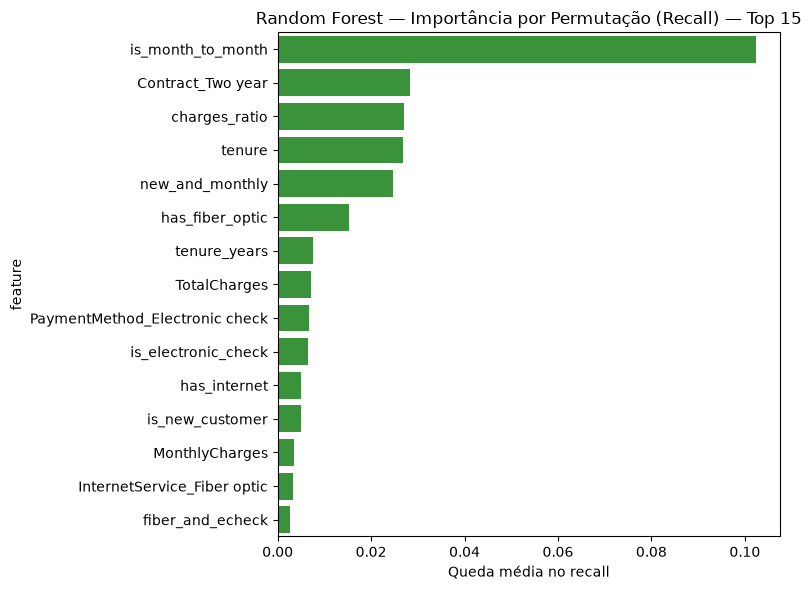

In [29]:
from sklearn.inspection import permutation_importance

perm_rf = permutation_importance(
    rf_model, X_test_final, y_test, scoring="recall", n_repeats=10, random_state=42, n_jobs=-1
)

perm_rf_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": perm_rf.importances_mean,
    "std": perm_rf.importances_std,
}).sort_values("importance", ascending=False)

display(perm_rf_df)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=perm_rf_df.head(15), x="importance", y="feature", color="#2ca02c", ax=ax)
ax.set_title("Random Forest — Importância por Permutação (Recall) — Top 15")
ax.set_xlabel("Queda média no recall")
plt.tight_layout()
plt.show()


## 4. Rede Neural simples — MLPClassifier

A Aula 5 descreve a rede neural como uma composição de transformações lineares e não lineares
(seção 1.1): cada camada calcula `z = w·x + b` e aplica uma ativação `a = f(z)`, e o empilhamento de
camadas permite representar fronteiras de decisão não lineares (seção 1.4) — diferente da Regressão
Logística, que é limitada a uma única fronteira linear no espaço de features.

**Escala das features (Aula 5, seção 2.6):** redes neurais são sensíveis à escala dos dados — entradas
em faixas muito diferentes (`tenure`: 0–72, `TotalCharges`: ~0–8700) dificultam a convergência do
gradiente. Por isso aplicamos o mesmo `StandardScaler` já usado para a Regressão Logística.

**Arquitetura:** com 18 features e ~5.600 amostras de treino, uma rede rasa e relativamente estreita já
é suficiente (Aula 5, seção 1.3 — profundidade e largura ampliam a capacidade, mas mais capacidade não
significa necessariamente um modelo melhor, seção 1.5). Usamos duas camadas ocultas moderadas.

**Otimizador e regularização (Aula 5, seções 2.3 e 2.4):** usamos `adam` (convergência geralmente
rápida e estável) e `early_stopping=True`, que interrompe o treino quando a perda de validação para de
melhorar — a mesma lógica de early stopping detalhada na Aula 5 (seção 3.2, curva de aprendizado) e na
Aula 6 (seção 1.4, tuning econômico) para evitar overfitting.

**Limitação conhecida:** diferente do Random Forest, o `MLPClassifier` do scikit-learn **não aceita**
`class_weight` nem `sample_weight` — o desbalanceamento não é tratado automaticamente nesse modelo. Isso
já foi observado na comparação de algoritmos da Etapa 1 (recall mais baixo do MLP frente aos modelos com
peso balanceado). Vamos medir o efeito disso na validação cruzada e no teste.

In [30]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        alpha=1e-4,               # regularização L2 (weight decay) — Aula 5, seção 2.4
        early_stopping=True,      # interrompe o treino quando a validação para de melhorar
        n_iter_no_change=15,
        max_iter=500,
        random_state=42,
    )),
])

mlp_cv_results = cross_validate(
    mlp_pipeline, X_train_final, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1
)

print("=== MLP (Rede Neural) — Validação Cruzada (5-fold estratificado) ===\n")
for metric in cv_scoring:
    scores = mlp_cv_results[f"test_{metric}"]
    print(f"{metric:>10s}: média={scores.mean():.4f}  desvio={scores.std():.4f}")


=== MLP (Rede Neural) — Validação Cruzada (5-fold estratificado) ===

    recall: média=0.5110  desvio=0.0198
   roc_auc: média=0.8337  desvio=0.0076
        f1: média=0.5703  desvio=0.0142
 precision: média=0.6460  desvio=0.0210
  accuracy: média=0.7957  desvio=0.0070


In [31]:
mlp_pipeline.fit(X_train_final, y_train)

y_pred_mlp = mlp_pipeline.predict(X_test_final)
y_proba_mlp = mlp_pipeline.predict_proba(X_test_final)[:, 1]

print("=== MLP (Rede Neural) — Conjunto de Teste ===\n")
print(classification_report(y_test, y_pred_mlp, target_names=["Não Churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_mlp):.4f}")
print(f"MCC:     {matthews_corrcoef(y_test, y_pred_mlp):.4f}")
print(f"\nMatriz de Confusão:\n{confusion_matrix(y_test, y_pred_mlp)}")


=== MLP (Rede Neural) — Conjunto de Teste ===

              precision    recall  f1-score   support

   Não Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8323
MCC:     0.4599

Matriz de Confusão:
[[927 108]
 [174 200]]


### Tuning de Hiperparâmetros — MLPClassifier

A Aula 5 (seções 1.3 e 2.4) destaca que profundidade, largura, taxa de aprendizado e regularização
(`alpha`, equivalente ao weight decay) são as decisões mais sensíveis no treino de uma rede neural —
mais capacidade não significa necessariamente um modelo melhor, e a taxa de aprendizado é descrita como
"o botão mais sensível do treino". Por isso o espaço de busca abaixo cobre justamente esses
hiperparâmetros: arquitetura (`hidden_layer_sizes`), regularização (`alpha`) e taxa de aprendizado inicial
(`learning_rate_init`), mantendo `early_stopping=True` para conter o custo de cada treino individual.

Como cada MLP treina mais devagar que uma árvore, usamos `n_iter=60` — menor que o do Random Forest,
mas ainda numa ordem de grandeza comparável, para manter a busca equilibrada entre os candidatos
sem deixar o tempo total de execução do notebook excessivo.

In [32]:
mlp_param_distributions = {
    "model__hidden_layer_sizes": [(16,), (32,), (32, 16), (64, 32), (64, 32, 16)],
    "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "model__learning_rate_init": [1e-3, 5e-4, 1e-4],
}

mlp_search = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=mlp_param_distributions,
    n_iter=60,
    scoring="recall",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
mlp_search.fit(X_train_final, y_train)

print(f"Melhores hiperparâmetros (MLP): {mlp_search.best_params_}")
print(f"Melhor recall médio em CV: {mlp_search.best_score_:.4f}")

# Substitui o pipeline "de bom senso" pelo pipeline tunado — usado no restante do notebook
mlp_pipeline = mlp_search.best_estimator_


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores hiperparâmetros (MLP): {'model__learning_rate_init': 0.0001, 'model__hidden_layer_sizes': (16,), 'model__alpha': 1e-05}
Melhor recall médio em CV: 0.5552


In [33]:
# Recalcula validação cruzada e avaliação em teste com o MLP já tunado
mlp_cv_results = cross_validate(mlp_pipeline, X_train_final, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1)

y_pred_mlp = mlp_pipeline.predict(X_test_final)
y_proba_mlp = mlp_pipeline.predict_proba(X_test_final)[:, 1]

print("=== MLP (tunado) — Conjunto de Teste ===\n")
print(classification_report(y_test, y_pred_mlp, target_names=["Não Churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_mlp):.4f}")
print(f"MCC:     {matthews_corrcoef(y_test, y_pred_mlp):.4f}")
print(f"\nMatriz de Confusão:\n{confusion_matrix(y_test, y_pred_mlp)}")


=== MLP (tunado) — Conjunto de Teste ===

              precision    recall  f1-score   support

   Não Churn       0.84      0.88      0.86      1035
       Churn       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.78      0.79      0.79      1409

ROC-AUC: 0.8373
MCC:     0.4473

Matriz de Confusão:
[[908 127]
 [167 207]]


### Curva de aprendizado (loss) do MLP

A Aula 5 (seção 3.2, Figura 5) mostra a curva de perda de treino vs. validação como diagnóstico de
overfitting: a perda de treino tende a cair continuamente, enquanto a de validação desce, estabiliza e
pode voltar a subir — o ponto de early stopping é onde a validação atinge seu melhor valor. Vale inspecionar
essa curva para confirmar que o treino convergiu de forma saudável, sem sinais de overfitting nem de
gradiente saturado.

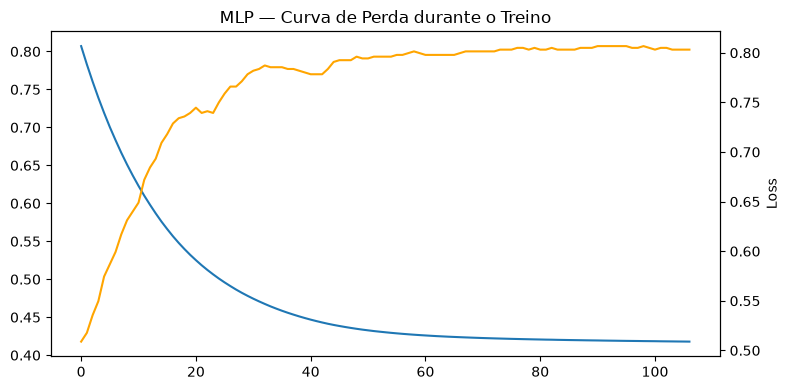

Número de épocas até convergência/early stopping: 107


In [34]:
mlp_final = mlp_pipeline.named_steps["model"]

plt.figure(figsize=(8, 4))
plt.plot(mlp_final.loss_curve_, label="Loss (treino)")
if hasattr(mlp_final, "validation_scores_") and mlp_final.validation_scores_:
    plt.twinx()
    plt.plot(mlp_final.validation_scores_, color="orange", label="Score (validação)")
plt.title("MLP — Curva de Perda durante o Treino")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

print(f"Número de épocas até convergência/early stopping: {mlp_final.n_iter_}")


## 5. Recarregar o modelo linear (Regressão Logística) para comparação

Para comparar os três tipos de modelo (Linear, Árvore, MLP) sobre exatamente os mesmos dados e a mesma
validação cruzada, recarregamos o modelo de Regressão Logística já tunado na Etapa 1, registrado no
MLflow (`run_id` do modelo campeão do tuning).

In [10]:
import mlflow

# Substitua pelo run_id do modelo de Regressão Logística tunado na Etapa 1
LOGISTIC_RUN_ID = "f8da89fbaa0148d0afd4b254c272e515"

logistic_model = mlflow.sklearn.load_model(f"runs:/{LOGISTIC_RUN_ID}/model")

# Validação cruzada do modelo linear, para comparação justa com RF e MLP
logistic_cv_results = cross_validate(
    logistic_model, X_train_final, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1
)

print("=== Regressão Logística (linear) — Validação Cruzada (5-fold estratificado) ===\n")
for metric in cv_scoring:
    scores = logistic_cv_results[f"test_{metric}"]
    print(f"{metric:>10s}: média={scores.mean():.4f}  desvio={scores.std():.4f}")

y_pred_logistic = logistic_model.predict(X_test_final)
y_proba_logistic = logistic_model.predict_proba(X_test_final)[:, 1]


=== Regressão Logística (linear) — Validação Cruzada (5-fold estratificado) ===

    recall: média=0.8870  desvio=0.0119
   roc_auc: média=0.8246  desvio=0.0097
        f1: média=0.5769  desvio=0.0022
 precision: média=0.4275  desvio=0.0035
  accuracy: média=0.6548  desvio=0.0052


## 6. Comparação dos modelos (Linear, Árvore/Ensemble, MLP)

Seguindo a Aula 6 (Parte 1 e 2), a comparação não deve se basear apenas em acurácia — especialmente
num dataset desbalanceado como este (73,5%/26,5%), em que um classificador ingênuo já acertaria 73,5%
sem identificar nenhum cliente em risco (Aula 6, seção 1.2 e 2.3).

Métricas reunidas por modelo:
- **Recall** — métrica de negócio prioritária (Aula 6, seção 1.3): minimizar falsos negativos.
- **ROC-AUC** — mede a separabilidade global do modelo, independente do desbalanceamento (Aula 6, seção 2.5).
- **F1** — equilíbrio entre precisão e recall (Aula 6, seção 2.4).
- **MCC** — combina todos os quadrantes da matriz de confusão num único coeficiente, especialmente útil
  em bases desbalanceadas (Aula 6, seção 2.7).
- **Desvio-padrão da validação cruzada** — indica a estabilidade de cada modelo entre os folds (Aula 4, seção 1.5).

Além do ROC-AUC, incluímos o **PR-AUC** (`average_precision_score`) na tabela comparativa.
Como discutido na Aula 6 (seção 2.5), a curva Precisão-Recall é mais sensível quando a classe positiva
é rara — que é exatamente o caso do churn (26,5% da base). Um ROC-AUC alto pode coexistir com precisão
baixa quando a base é dominada por negativos (seção 2.6, "armadilha a evitar"), então o PR-AUC funciona
como um contraponto que evita uma leitura otimista demais só pelo ROC-AUC.

In [41]:
from sklearn.metrics import average_precision_score

def summarize_model(name, cv_results, y_true, y_pred, y_proba):
    return {
        "Modelo": name,
        "CV Recall (média)": cv_results["test_recall"].mean(),
        "CV Recall (desvio)": cv_results["test_recall"].std(),
        "CV ROC-AUC (média)": cv_results["test_roc_auc"].mean(),
        "Teste - Acurácia": accuracy_score(y_true, y_pred),
        "Teste - Precisão": precision_score(y_true, y_pred),
        "Teste - Recall": recall_score(y_true, y_pred),
        "Teste - F1": f1_score(y_true, y_pred),
        "Teste - ROC-AUC": roc_auc_score(y_true, y_proba),
        "Teste - PR-AUC": average_precision_score(y_true, y_proba),
        "Teste - MCC": matthews_corrcoef(y_true, y_pred),
    }

comparison_rows = [
    summarize_model("Logistic Regression (Linear)", logistic_cv_results, y_test, y_pred_logistic, y_proba_logistic),
    summarize_model("Random Forest (Ensemble)", rf_cv_results, y_test, y_pred_rf, y_proba_rf),
    summarize_model("MLP (Rede Neural)", mlp_cv_results, y_test, y_pred_mlp, y_proba_mlp),
]

comparison_df = pd.DataFrame(comparison_rows).round(4)
comparison_df.sort_values("Teste - Recall", ascending=False).reset_index(drop=True)


,Modelo,CV Recall (média),CV Recall (desvio),CV ROC-AUC (média),Teste - Acurácia,Teste - Precisão,Teste - Recall,Teste - F1,Teste - ROC-AUC,Teste - PR-AUC,Teste - MCC
0,Logistic Regression (Linear),0.8870,0.0119,0.8246,0.6615,0.4323,0.8797,0.5797,0.8260,0.6242,0.4096
1,Random Forest (Ensemble),0.7987,0.0153,0.8423,0.7502,0.5194,0.7888,0.6263,0.8432,0.6493,0.4726
2,MLP (Rede Neural),0.5552,0.0239,0.8235,0.7913,0.6198,0.5535,0.5847,0.8373,0.6444,0.4473


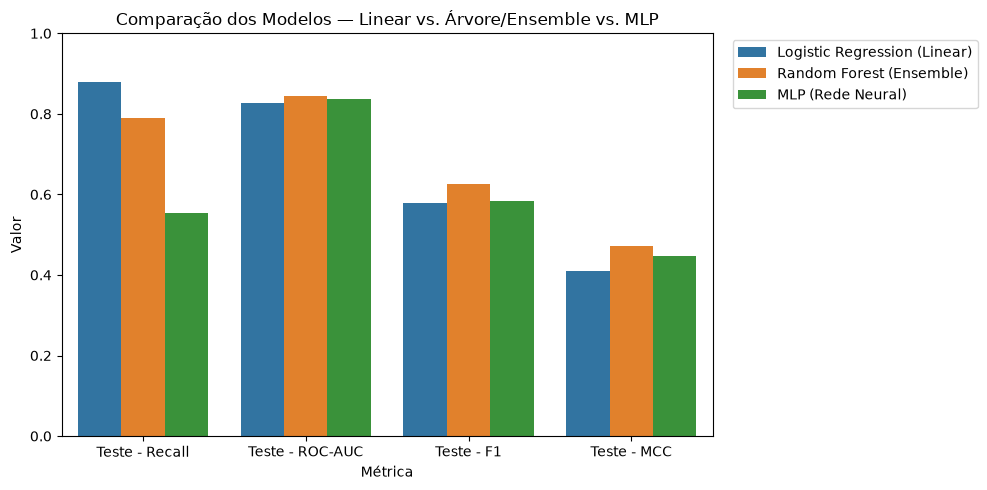

In [42]:
# Visualização comparativa
metrics_to_plot = ["Teste - Recall", "Teste - ROC-AUC", "Teste - F1", "Teste - MCC"]
plot_df = comparison_df.melt(id_vars="Modelo", value_vars=metrics_to_plot,
                              var_name="Métrica", value_name="Valor")

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Métrica", y="Valor", hue="Modelo")
plt.title("Comparação dos Modelos — Linear vs. Árvore/Ensemble vs. MLP")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Curvas Precisão-Recall comparativas

Plotamos a curva PR de cada modelo — diferente da tabela de métricas pontuais (calculadas no threshold
padrão de 0,5), a curva mostra o compromisso entre precisão e recall em **todos** os thresholds possíveis,
permitindo enxergar qual modelo mantém melhor precisão à medida que se exige mais recall.

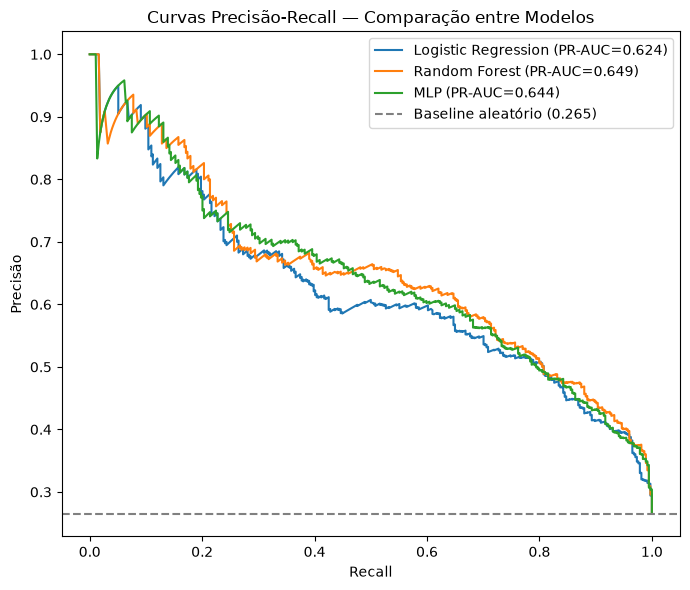

In [43]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(7, 6))

for name, y_proba in [
    ("Logistic Regression", y_proba_logistic),
    ("Random Forest", y_proba_rf),
    ("MLP", y_proba_mlp),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(rec, prec, label=f"{name} (PR-AUC={ap:.3f})")

# Linha de referência: taxa de positivos na base (desempenho de um classificador aleatório)
baseline_rate = y_test.mean()
ax.axhline(baseline_rate, color="gray", linestyle="--", label=f"Baseline aleatório ({baseline_rate:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precisão")
ax.set_title("Curvas Precisão-Recall — Comparação entre Modelos")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


## 7. Validação estatística da comparação

A Aula 6 (seção 3.4) alerta que comparar modelos só pela média de uma métrica é arriscado — a diferença
observada pode ser apenas ruído de amostragem do conjunto de teste, não uma diferença real de qualidade
entre os modelos ("evita decisões baseadas em diferenças de segunda casa decimal que podem ser apenas
ruído"). Aplicamos duas técnicas recomendadas no material:

- **Intervalos de confiança via bootstrap**: reamostramos o conjunto de teste com reposição, recalculamos
  a métrica muitas vezes, e obtemos uma distribuição empírica — útil para métricas sem fórmula de erro
  padrão simples, como Recall, F1 e AUC.
- **Teste de McNemar**: compara dois classificadores de forma pareada, avaliando se a diferença de erros
  entre eles é estatisticamente significativa (em vez de comparar só a métrica agregada).

In [44]:
def bootstrap_metric_ci(y_true, y_pred, y_proba, metric_fn, uses_proba=False, n_boot=1000, random_state=42):
    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_proba[idx]
        if len(np.unique(yt)) < 2:
            continue  # amostra sem as duas classes — pula, métrica não é definida
        if uses_proba:
            scores.append(metric_fn(yt, ypr))
        else:
            scores.append(metric_fn(yt, yp))
    scores = np.array(scores)
    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


models_for_ci = {
    "Logistic Regression": (y_pred_logistic, y_proba_logistic),
    "Random Forest": (y_pred_rf, y_proba_rf),
    "MLP": (y_pred_mlp, y_proba_mlp),
}

ci_rows = []
for name, (y_pred, y_proba) in models_for_ci.items():
    recall_mean, recall_lo, recall_hi = bootstrap_metric_ci(y_test, y_pred, y_proba, recall_score)
    roc_mean, roc_lo, roc_hi = bootstrap_metric_ci(y_test, y_pred, y_proba, roc_auc_score, uses_proba=True)
    pr_mean, pr_lo, pr_hi = bootstrap_metric_ci(y_test, y_pred, y_proba, average_precision_score, uses_proba=True)
    ci_rows.append({
        "Modelo": name,
        "Recall (média)": recall_mean, "Recall (IC 95%)": f"[{recall_lo:.3f}, {recall_hi:.3f}]",
        "ROC-AUC (média)": roc_mean, "ROC-AUC (IC 95%)": f"[{roc_lo:.3f}, {roc_hi:.3f}]",
        "PR-AUC (média)": pr_mean, "PR-AUC (IC 95%)": f"[{pr_lo:.3f}, {pr_hi:.3f}]",
    })

ci_df = pd.DataFrame(ci_rows).round(4)
print("=== Intervalos de Confiança via Bootstrap (1000 reamostragens, 95%) ===\n")
display(ci_df)

print("\nInterpretação: se os intervalos de dois modelos se sobrepõem substancialmente,")
print("a diferença observada entre eles pode não ser estatisticamente significativa.")


=== Intervalos de Confiança via Bootstrap (1000 reamostragens, 95%) ===



,Modelo,Recall (média),Recall (IC 95%),ROC-AUC (média),ROC-AUC (IC 95%),PR-AUC (média),PR-AUC (IC 95%)
0,Logistic Regression,0.8789,"[0.845, 0.912]",0.8258,"[0.803, 0.847]",0.6250,"[0.574, 0.672]"
1,Random Forest,0.7884,"[0.747, 0.828]",0.8433,"[0.822, 0.863]",0.6506,"[0.598, 0.698]"
2,MLP,0.5545,"[0.504, 0.604]",0.8375,"[0.816, 0.859]",0.6456,"[0.593, 0.694]"



Interpretação: se os intervalos de dois modelos se sobrepõem substancialmente,
a diferença observada entre eles pode não ser estatisticamente significativa.


### Teste de McNemar (comparação pareada)

O teste de McNemar avalia, para cada par de modelos, se a quantidade de casos em que **um acerta e o
outro erra** (nas duas direções) é significativamente diferente — respondendo diretamente se um modelo
é estatisticamente melhor que o outro nesse conjunto de teste, e não apenas numericamente maior.

In [45]:
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(y_true, y_pred_a, y_pred_b, name_a, name_b):
    y_true = np.asarray(y_true)
    correct_a = (np.asarray(y_pred_a) == y_true)
    correct_b = (np.asarray(y_pred_b) == y_true)

    # Tabela de contingência 2x2: quantos casos cada modelo acerta/erra em relação ao outro
    both_correct = np.sum(correct_a & correct_b)
    only_a_correct = np.sum(correct_a & ~correct_b)
    only_b_correct = np.sum(~correct_a & correct_b)
    both_wrong = np.sum(~correct_a & ~correct_b)

    table = [[both_correct, only_a_correct], [only_b_correct, both_wrong]]
    result = mcnemar(table, exact=False, correction=True)

    print(f"{name_a} vs. {name_b}")
    print(f"  Só {name_a} acerta: {only_a_correct} | Só {name_b} acerta: {only_b_correct}")
    print(f"  Estatística: {result.statistic:.4f}  |  p-valor: {result.pvalue:.4f}")
    if result.pvalue < 0.05:
        print("  → Diferença estatisticamente significativa (p < 0.05)")
    else:
        print("  → Diferença NÃO estatisticamente significativa (p >= 0.05)")
    print()

mcnemar_test(y_test, y_pred_logistic, y_pred_rf, "Logistic Regression", "Random Forest")
mcnemar_test(y_test, y_pred_logistic, y_pred_mlp, "Logistic Regression", "MLP")
mcnemar_test(y_test, y_pred_rf, y_pred_mlp, "Random Forest", "MLP")


Logistic Regression vs. Random Forest
  Só Logistic Regression acerta: 44 | Só Random Forest acerta: 169
  Estatística: 72.1878  |  p-valor: 0.0000
  → Diferença estatisticamente significativa (p < 0.05)

Logistic Regression vs. MLP
  Só Logistic Regression acerta: 124 | Só MLP acerta: 307
  Estatística: 76.8538  |  p-valor: 0.0000
  → Diferença estatisticamente significativa (p < 0.05)

Random Forest vs. MLP
  Só Random Forest acerta: 89 | Só MLP acerta: 147
  Estatística: 13.7669  |  p-valor: 0.0002
  → Diferença estatisticamente significativa (p < 0.05)



## 8. Escolha do modelo campeão

Com base na métrica de negócio definida (recall, priorizando minimizar falsos negativos) e na
robustez observada na validação cruzada (desvio-padrão entre folds), preenche-se a análise abaixo
com os números obtidos nas células anteriores antes de declarar o modelo campeão.

**Critério de decisão:**
1. Maior recall no conjunto de teste, sem ROC-AUC substancialmente pior que os demais candidatos.
2. Estabilidade entre folds (desvio-padrão do recall na validação cruzada) — um modelo com recall
   alto mas muito instável entre folds é um sinal de alerta.
3. Coerência entre CV e teste — se a métrica de teste destoa muito da média de CV, investigar overfitting
   ou uma divisão de teste pouco representativa.

In [37]:
champion_row = comparison_df.sort_values("Teste - Recall", ascending=False).iloc[0]
print("=== MODELO CAMPEÃO (por Recall) ===\n")
print(champion_row.to_string())



=== MODELO CAMPEÃO (por Recall) ===

Modelo                Logistic Regression (Linear)
CV Recall (média)                            0.887
CV Recall (desvio)                          0.0119
CV ROC-AUC (média)                          0.8246
Teste - Acurácia                            0.6615
Teste - Precisão                            0.4323
Teste - Recall                              0.8797
Teste - F1                                  0.5797
Teste - ROC-AUC                              0.826
Teste - MCC                                 0.4096


**Modelo campeão (pelo critério de negócio — Recall):** Logistic Regression, com recall de teste de
0,880 (IC 95% bootstrap: [0,845; 0,912]), contra 0,789 do Random Forest ([0,747; 0,828]) e 0,554 do
MLP ([0,504; 0,604]). A margem sobre o Random Forest (~9 p.p.) é estatisticamente robusta: os
intervalos de confiança não se sobrepõem, e o teste de McNemar confirma diferença significativa entre
os dois modelos (p < 0,0001). Ou seja, a superioridade de recall da Logistic Regression não é ruído de
amostragem — é uma diferença real neste conjunto de teste.

**A escolha é sensível ao critério.** Se o desempate fosse por outra métrica, o campeão mudaria:

| Critério | Campeão | Valor |
|---|---|---|
| Recall (negócio) | Logistic Regression | 0,880 |
| F1 | Random Forest | 0,626 |
| ROC-AUC | Random Forest | 0,843 |
| PR-AUC | Random Forest | 0,649 |
| MCC | Random Forest | 0,473 |

Em **todas as métricas que equilibram precisão e recall** (F1, MCC) ou medem separabilidade global
(ROC-AUC, PR-AUC), o Random Forest vence — e por uma margem maior que a diferença de recall entre eles.
O MCC é o caso mais revelador: apesar do recall altíssimo, a Logistic Regression tem o **menor MCC dos
três modelos** (0,410, contra 0,473 do RF), sinal de que sua qualidade preditiva *global* (considerando
os quatro quadrantes da matriz de confusão) é a mais fraca do grupo — o alto recall é comprado com uma
precisão de apenas 0,432 (menos da metade dos clientes sinalizados como risco realmente cancelariam) e
uma acurácia de 0,662.

**Vale notar que a diferença de ROC-AUC e PR-AUC entre os três modelos não é claramente significativa**:
os intervalos de confiança bootstrap se sobrepõem substancialmente entre LR, RF e MLP nessas duas
métricas — então, embora RF tenha o melhor ponto estimado em ambas, não é possível afirmar com confiança
estatística que ele discrimina melhor as classes do que os outros dois modelos apenas com base nelas.

**Decisão:** seguindo estritamente a métrica de negócio definida na Etapa 1 (recall como prioridade,
para minimizar falsos negativos de churn), a **Logistic Regression é declarada o modelo campeão formal**
desta etapa. Registra-se, porém, o **Random Forest como candidato forte alternativo**, dado seu melhor
equilíbrio geral (MCC, F1, acurácia) — a decisão final de produção deve considerar se a área de negócio
está disposta a arcar com a baixa precisão da Logistic Regression (muitas ações de retenção
desnecessárias) em troca do recall mais alto, ou se prefere um modelo mais equilibrado como o Random
Forest, possivelmente combinado com um ajuste de threshold (abaixo de 0,5) para aumentar seu recall sem
abrir mão de tanta precisão quanto a Logistic Regression.

## 9. Registrar os resultados dos experimentos

Registramos os três modelos como runs no MLflow, dentro de um novo experimento dedicado à Etapa 2 —
permitindo comparar lado a lado, na UI do MLflow, os resultados de CV e teste de cada candidato, além
de manter os artefatos de modelo versionados para a etapa seguinte (empacotamento/API).

In [16]:
mlflow.set_experiment("telco_churn_etapa2_modelagem")

def log_model_run(run_name, model, cv_results, y_true, y_pred, y_proba, extra_params=None):
    with mlflow.start_run(run_name=run_name):
        if extra_params:
            for k, v in extra_params.items():
                mlflow.log_param(k, v)

        for metric in cv_scoring:
            scores = cv_results[f"test_{metric}"]
            mlflow.log_metric(f"cv_{metric}_mean", float(scores.mean()))
            mlflow.log_metric(f"cv_{metric}_std", float(scores.std()))

        mlflow.log_metric("test_accuracy", accuracy_score(y_true, y_pred))
        mlflow.log_metric("test_precision", precision_score(y_true, y_pred))
        mlflow.log_metric("test_recall", recall_score(y_true, y_pred))
        mlflow.log_metric("test_f1", f1_score(y_true, y_pred))
        mlflow.log_metric("test_roc_auc", roc_auc_score(y_true, y_proba))
        mlflow.log_metric("test_mcc", matthews_corrcoef(y_true, y_pred))

        mlflow.sklearn.log_model(model, "model", serialization_format="pickle")
        print(f"✓ Run registrado: {run_name}")


log_model_run(
    "logistic_regression_etapa2",
    logistic_model, logistic_cv_results, y_test, y_pred_logistic, y_proba_logistic,
    extra_params={"tipo": "linear", "class_weight": "balanced"},
)

log_model_run(
    "random_forest_etapa2",
    rf_model, rf_cv_results, y_test, y_pred_rf, y_proba_rf,
    extra_params={"tipo": "ensemble_arvore", "n_estimators": 200, "class_weight": "balanced"},
)

log_model_run(
    "mlp_etapa2",
    mlp_pipeline, mlp_cv_results, y_test, y_pred_mlp, y_proba_mlp,
    extra_params={"tipo": "rede_neural", "hidden_layer_sizes": "(32, 16)", "solver": "adam"},
)

print("\n✓ Todos os experimentos registrados no MLflow (experimento: telco_churn_etapa2_modelagem).")


2026/08/21 17:39:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/21 17:39:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/21 17:39:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/08/21 17:39:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/21 17:39:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, wh

✓ Run registrado: logistic_regression_etapa2


2026/08/21 17:39:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/08/21 17:39:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✓ Run registrado: random_forest_etapa2


2026/08/21 17:39:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/21 17:39:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✓ Run registrado: mlp_etapa2

✓ Todos os experimentos registrados no MLflow (experimento: telco_churn_etapa2_modelagem).


### Tabela-resumo para registro (alternativa em texto/planilha)

Além do MLflow, a tabela `comparison_df` já gerada pode ser exportada diretamente como um registro
simples em CSV — útil como anexo de relatório, independentemente de ferramentas de tracking.

In [46]:
os.makedirs("data/processed", exist_ok=True)
comparison_df.to_csv("data/processed/etapa2_comparacao_modelos.csv", index=False)
print("✓ Tabela de comparação salva em: data/processed/etapa2_comparacao_modelos.csv")


✓ Tabela de comparação salva em: data/processed/etapa2_comparacao_modelos.csv


### Salvar o modelo campeão em disco (.joblib)

Além do registro no MLflow, persistimos o modelo campeão como arquivo `.joblib` — formato simples e
portável, que a próxima etapa (empacotamento na arquitetura modular e exposição via FastAPI) pode
carregar diretamente, sem depender do MLflow em produção. Também salvamos o Random Forest como
candidato alternativo documentado, dada a discussão de trade-off na Seção 8.

In [47]:
import joblib

os.makedirs("models", exist_ok=True)

# Modelo campeão: Logistic Regression (critério de negócio — recall)
joblib.dump(logistic_model, "models/champion_model.joblib")
print("✓ Modelo campeão salvo em: models/champion_model.joblib")

# Candidato alternativo documentado: Random Forest (melhor equilíbrio F1/MCC/ROC-AUC/PR-AUC)
joblib.dump(rf_model, "models/random_forest_alternative.joblib")
print("✓ Modelo alternativo salvo em: models/random_forest_alternative.joblib")


✓ Modelo campeão salvo em: models/champion_model.joblib
✓ Modelo alternativo salvo em: models/random_forest_alternative.joblib


## Conclusão da Etapa 2

**Modelo campeão:** Logistic Regression, pelo critério de negócio definido (recall = 0,880, IC 95%
[0,845; 0,912], estatisticamente superior ao Random Forest via bootstrap e McNemar). O Random Forest
(recall = 0,789) é o candidato alternativo mais forte, vencendo em todas as métricas de equilíbrio
(F1 = 0,626, MCC = 0,473, ROC-AUC = 0,843, PR-AUC = 0,649) e com estabilidade em CV compatível
(desvio-padrão de recall de 0,015, próximo ao 0,012 da Logistic Regression). O MLP ficou consistentemente
em último lugar na métrica de negócio (recall = 0,554), mesmo após tuning.

**Random Forest e os conceitos da Aula 4:** o tuning evidenciou na prática o trade-off viés/variância
discutido na aula — o modelo "de bom senso" inicial (profundidade padrão) teve recall de apenas 0,641 em
CV; o `RandomizedSearchCV` convergiu para árvores rasas (`max_depth=5`, `min_samples_leaf=7`) dentro do
ensemble, elevando o recall em CV para 0,799. Isso confirma a lógica de bagging + sub-amostragem de
atributos da aula: árvores mais simples e menos correlacionadas entre si generalizam melhor para a
classe minoritária do que árvores individualmente mais profundas. O OOB score (0,769) ficou muito
próximo da acurácia observada em CV e teste, validando-o como proxy barato de validação interna. A
importância por permutação confirmou os achados da Etapa 1: `is_month_to_month`, `Contract_Two year`,
`charges_ratio` e `tenure` dominam o poder preditivo do modelo — coerente com o Cramér's V calculado no
EDA.

**MLP e os conceitos da Aula 5:** a normalização via `StandardScaler` dentro do pipeline foi essencial
para a convergência, e a curva de perda mostrou um treino saudável — perda de treino caindo de forma
suave até estabilizar por volta de 0,42, com o score de validação subindo e estabilizando por volta da
época 60–100, sem sinais de divergência (early stopping ativado corretamente). Ainda assim, o MLP
confirmou empiricamente a limitação já antecipada: por não suportar `class_weight` nem `sample_weight`,
o desbalanceamento (73,5%/26,5%) nunca foi tratado nesse modelo. O tuning por `RandomizedSearchCV`
(otimizando recall) convergiu para uma arquitetura pequena (uma única camada de 16 neurônios) com baixa
regularização e taxa de aprendizado lenta — uma melhora real frente ao modelo inicial (recall subiu de
0,511 para 0,555 em CV), mas insuficiente para se aproximar dos modelos com peso balanceado. Isso reforça
que, para essa rede, seria necessário um mecanismo externo de rebalanceamento (ex.: SMOTE no treino, ou
ajuste de threshold pós-treino) para competir em recall.

**Leitura das métricas de negócio (Aula 6):** a comparação confirmou por que accuracy isolada seria
enganosa aqui — o MLP tem a maior acurácia (0,791) e ainda assim o pior recall dos três, exatamente o
padrão de "armadilha" descrito na aula para bases desbalanceadas. As curvas Precisão-Recall mostraram os
três modelos claramente acima do baseline aleatório (0,265), com PR-AUCs próximos (0,624–0,649) e
intervalos de confiança sobrepostos — ou seja, a separabilidade "bruta" dos três modelos é estatisticamente
parecida; o que os diferencia de fato é **onde cada um posiciona seu threshold implícito** na fronteira
precisão-recall, e é aí que a definição de métrica de negócio (recall) se torna decisiva para desempatar
a favor da Logistic Regression. Os testes de McNemar confirmaram que todas as diferenças par-a-par entre
os três modelos são estatisticamente significativas (p < 0,001 em todos os pares) — validando que a
escolha do modelo não é uma questão de ruído estatístico, mas de qual perfil de erro (falsos positivos
vs. falsos negativos) é mais aceitável para o negócio.

**Encaminhamento para a próxima etapa:** a Logistic Regression segue como modelo campeão formal para
empacotamento na arquitetura modular e exposição via FastAPI, com o Random Forest documentado como
alternativa de maior equilíbrio operacional. Antes do empacotamento final, recomenda-se uma etapa de
calibração de threshold (para ambos os candidatos) para explorar se é possível aproximar o recall do
Random Forest ao da Logistic Regression sem herdar sua baixa precisão — decisão que deve ser validada
com a área de negócio antes de fechar o modelo definitivo da API.